# Mastering Unsupervised Learning: Clustering Techniques
This tutorial covers the two most popular clustering methods: **K-Means** and **Agglomerative Hierarchical Clustering**, including how to validate your results using the Elbow Method and Silhouette Scores.

## 1. Data Preparation
We start by loading our customer data and cleaning the column names for easier access.

In [1]:
!pip install seaborn scipy



## K-Nearest Neighbors (KNN) Algorithm

**Note:** KNN is a **supervised** learning algorithm (unlike K-Means which is unsupervised). It classifies a new point based on the labels of its closest neighbors in the training data.

### Steps

1. **Choose K** — pick the number of neighbors to consider (e.g., K=5).
2. **Calculate distance** — for a new point $x$, compute the distance to every point in the training set.
3. **Find K nearest neighbors** — select the K training points closest to $x$.
4. **Vote (classification)** — the predicted class is the most common class among those K neighbors. For regression, it's the average of their values.

### Distance Metrics

The most common is **Euclidean distance**:

$$d(x, x_i) = \sqrt{\sum_{j=1}^{n} (x_j - x_{i,j})^2}$$

- $x$ = new data point
- $x_i$ = a training data point
- $n$ = number of features

Other options include **Manhattan distance**:

$$d(x, x_i) = \sum_{j=1}^{n} |x_j - x_{i,j}|$$

### Classification Decision

For classification, the predicted label $\hat{y}$ is:

$$\hat{y} = \text{mode}(\{y_i : x_i \in N_K(x)\})$$

where $N_K(x)$ is the set of K nearest neighbors of $x$.

### Key Considerations

- **K is odd** (for binary classification) to avoid ties
- **Feature scaling matters** — features with larger ranges dominate the distance calculation, so normalize/standardize first
- **Small K** = more sensitive to noise; **Large K** = smoother boundaries but may lose detail
- **No training phase** — KNN is a "lazy learner" that stores all data and computes at prediction time

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# Load dataset
# Note: Ensure 'customers.csv' is in your directory or use the sample data below
try:
    df = pd.read_csv('datafiles/customers.csv')
except:
    # Creating dummy data if file is missing to ensure code runs
    from sklearn.datasets import make_blobs
    X, _ = make_blobs(n_samples=200, centers=4, cluster_std=1.0, random_state=0)
    df = pd.DataFrame(X, columns=['age', 'spending'])

df.columns = ['customer_id', 'gender', 'age', 'income', 'spending'] if len(df.columns) == 5 else ['age', 'spending']
df.head()

,age,spending
0,2.353506,2.224050
1,-0.740576,2.451463
2,1.153696,3.902006
3,-3.503820,6.812953
4,1.310513,0.071225


## 2. Finding the Optimal K: The Elbow Method
The **Elbow Method** looks at the total **Inertia** (sum of squared errors). We look for the "elbow" point where adding another cluster doesn't significantly reduce the error.

### Math Behind the Elbow and Silhouette Methods
#### Elbow Method (Inertia)
- **Inertia** is the sum of squared distances from each point to its assigned cluster center:
  $$\text{Inertia} = \sum_{i=1}^{K} \sum_{x \in C_i} \| x - \mu_i \|^2$$
  - $K$ = number of clusters
  - $C_i$ = set of points in cluster $i$
  - $\mu_i$ = centroid of cluster $i$
  - $x$ = a data point
- As $K$ increases, inertia decreases. The "elbow" is the point where adding more clusters does not significantly reduce inertia, suggesting a good $K$.

#### Silhouette Score
- Measures how well each point fits within its cluster compared to other clusters.
- For a point $i$:
  - $a(i)$ = average distance to all other points in the same cluster
  - $b(i)$ = lowest average distance to points in any other cluster (nearest neighbor cluster)
- The silhouette score for point $i$ is:
  $$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$
  - $s(i)$ ranges from -1 to 1:
    - Close to 1: well-matched to its own cluster, poorly matched to others
    - Close to 0: on the boundary between clusters
    - Negative: may be assigned to the wrong cluster
- The overall silhouette score is the mean of $s(i)$ for all points.

#### More Detailed Explanation of K-Means Steps
- **Initialization:** The algorithm starts by picking $K$ random points as the initial centroids (centers of clusters).
- **Assignment Step:** For each data point, calculate the distance to each centroid. Assign the point to the cluster whose centroid is closest. This forms $K$ groups.
- **Update Step:** For each cluster, recalculate the centroid by taking the mean (average) of all points assigned to that cluster. The centroid moves to this new position.
- **Repeat:** The assignment and update steps are repeated. After each iteration, points may switch clusters as centroids move. The process continues until either:
  - No points change clusters (convergence), or
  - A maximum number of iterations is reached.
- **Result:** The final clusters are those where each point is closer to its own centroid than to any other centroid. The centroids represent the "center" of each group.

**Why does this work?**
- Each iteration reduces the total sum of squared distances (inertia) between points and their centroids.
- The algorithm finds a local minimum of the inertia, grouping similar points together.

### How K-Means Groups Are Calculated
K-Means clustering groups data by minimizing the distance between points and their assigned cluster centers (centroids).
#### Steps:
1. **Initialize** $K$ centroids (randomly or by a smart method like k-means++).
2. **Assign** each data point to the nearest centroid using Euclidean distance:
   $$\text{Assign } x_j \text{ to cluster } i^* = \arg\min_{i} \| x_j - \mu_i \|$$
   - $x_j$ is a data point, $\mu_i$ is the centroid of cluster $i$.
3. **Update** each centroid to be the mean of all points assigned to it:
   $$\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x$$
   - $C_i$ is the set of points in cluster $i$.
4. **Repeat** steps 2 and 3 until assignments stop changing or a maximum number of iterations is reached.
This process ensures that each group (cluster) contains points that are as close as possible to their centroid.

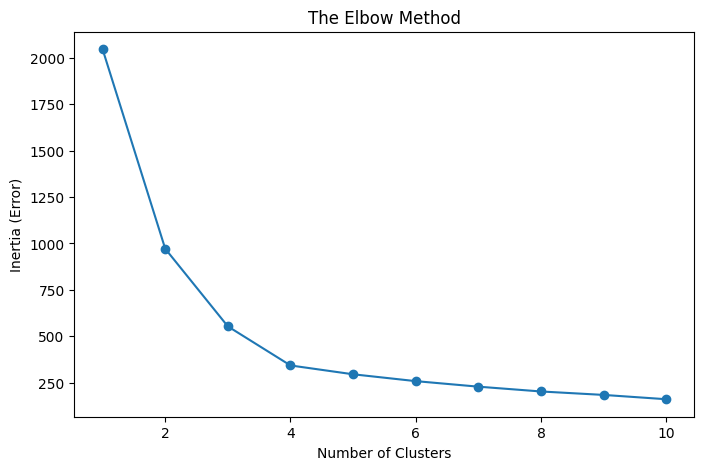

Based on the plot, the 'Elbow' appears at K=4.


array([7, 6, 4, 3, 0, 9, 2, 4, 9, 9, 4, 0, 2, 2, 7, 9, 8, 8, 3, 4, 3, 6,
       0, 6, 7, 5, 1, 5, 5, 9, 1, 9, 6, 7, 6, 9, 6, 9, 9, 3, 1, 8, 8, 4,
       5, 2, 4, 3, 3, 9, 8, 6, 2, 8, 7, 1, 6, 0, 1, 7, 3, 4, 7, 9, 3, 4,
       5, 3, 2, 6, 0, 5, 9, 6, 2, 1, 6, 2, 7, 0, 8, 9, 7, 5, 2, 6, 9, 0,
       6, 2, 8, 8, 3, 1, 9, 5, 2, 3, 7, 1, 8, 5, 7, 3, 8, 6, 9, 7, 7, 4,
       8, 6, 2, 5, 0, 9, 5, 2, 1, 4, 8, 2, 9, 0, 4, 2, 4, 2, 5, 9, 2, 4,
       4, 8, 8, 2, 8, 8, 0, 8, 5, 2, 7, 5, 5, 0, 9, 7, 2, 3, 8, 3, 4, 2,
       5, 1, 3, 2, 8, 4, 3, 0, 0, 6, 6, 8, 4, 5, 7, 2, 4, 4, 6, 8, 3, 8,
       1, 1, 6, 1, 4, 0, 9, 5, 4, 2, 2, 3, 1, 8, 5, 0, 9, 1, 2, 2, 6, 9,
       1, 4], dtype=int32)

In [3]:
errors = []
X = df[['age', 'spending']]

for n in range(1, 11):
    my_kmeans = KMeans(n_clusters=n, random_state=0, n_init=10)
    my_kmeans.fit(X)
    errors.append(my_kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), errors, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Error)')
plt.show()

print("Based on the plot, the 'Elbow' appears at K=4.")
my_kmeans.labels_

## 3. Validating with Silhouette Score
The **Silhouette Score** measures how similar an object is to its own cluster compared to others.
* **Close to 1:** Well-separated clusters.
* **Close to 0:** Overlapping clusters.
* **Negative:** Likely assigned to the wrong cluster.

In [4]:
s_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)
    score = silhouette_score(X, kmeans.labels_)
    s_scores.append(score)

optimal_k = np.argmax(s_scores) + 2
print(f"Optimal number of clusters based on Silhouette Score: {optimal_k}")

Optimal number of clusters based on Silhouette Score: 4


## 4. Final K-Means Model & Visualization
We now run the model with K=4 and visualize the results and their centers (centroids).

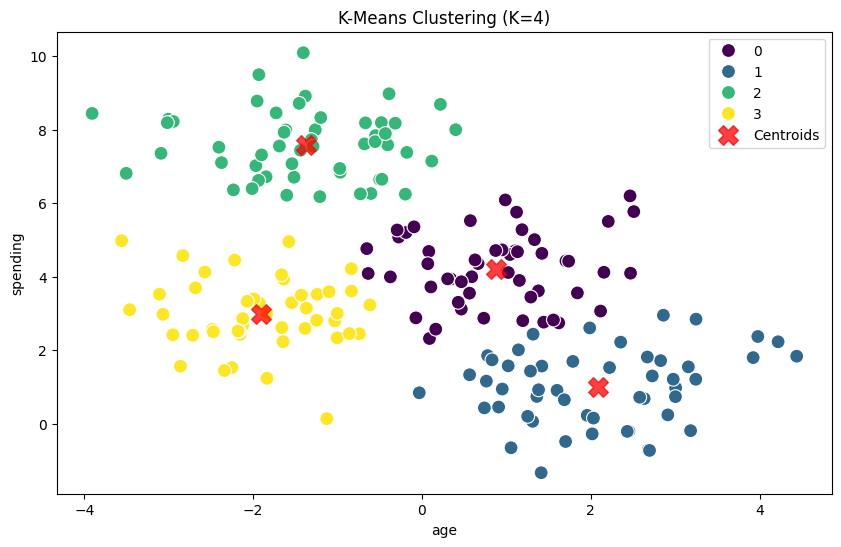

In [5]:
final_kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
df['clusters'] = final_kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='spending', hue='clusters', palette='viridis', s=100)

# Plotting Centers
centers = final_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.title("K-Means Clustering (K=4)")
plt.legend()
plt.show()

## 5. Hierarchical Clustering & Dendrograms
Hierarchical clustering builds a tree of clusters. We use **Ward's Linkage**, which minimizes the variance (ESS) when merging clusters.

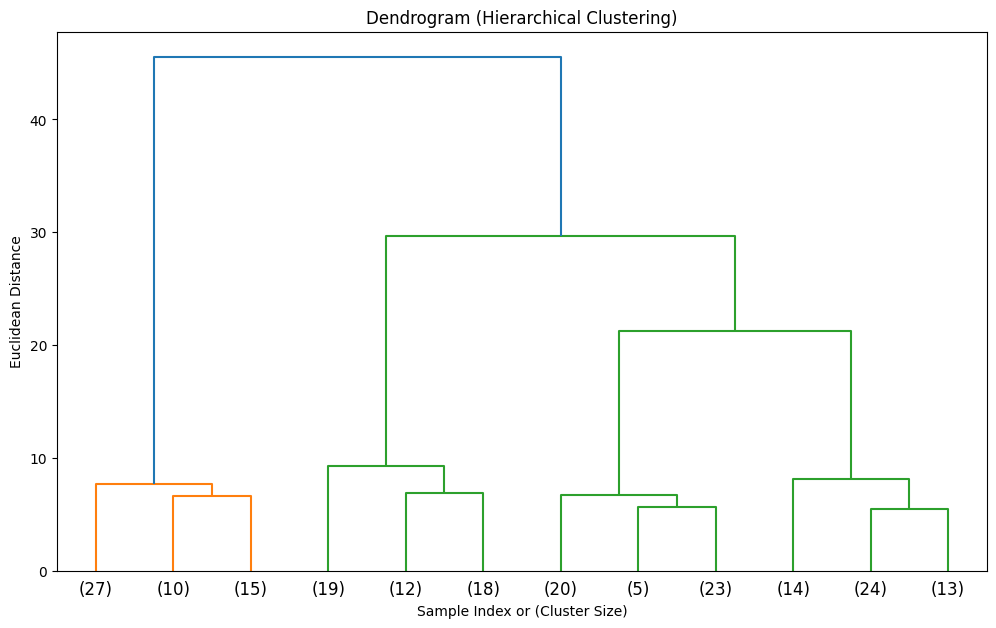

In [6]:
# Create Linkage Matrix
my_lnk = linkage(X, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(my_lnk, orientation='top', truncate_mode='lastp', p=12)
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Euclidean Distance')
plt.show()

## 6. Business Conclusions
By segmenting the data, we can identify four distinct customer personas:
1. **Cluster 0:** Middle-age customers with low spending.
2. **Cluster 1:** Young customers with high spending.
3. **Cluster 2:** Young customers with moderate spending.
4. **Cluster 3:** Senior customers with moderate spending.